# Step 5: Virtual Screening of Approved Drugs for EGFR Repurposing

We apply the trained XGBoost model to screen a large library of clinically approved
small molecule drugs retrieved from ChEMBL (max_phase = 4). By predicting EGFR binding
affinity for compounds originally approved for other indications, we identify potential
drug repurposing candidates. Compounds already present in the EGFR training set are
excluded to avoid data leakage.

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw
from rdkit import DataStructs
from PIL import Image
from io import BytesIO
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

best_model = joblib.load('../models/best_model.pkl')
metadata = joblib.load('../models/metadata.pkl')
scaler = joblib.load('../models/scaler.pkl')

print(f'Model: {metadata["best_model"]}')
print(f'Test R\u00b2: {metadata["best_r2"]:.4f}')
print(f'Expected features: {metadata["n_features"]}')

Model: XGBoost
Test R²: 0.7357
Expected features: 2060


## 5.1 Compound Library Assembly

We query ChEMBL for all small molecule drugs that have reached phase 4 (approved).
We retain only compounds with valid canonical SMILES and remove any that are already
present in the EGFR training set (by `molecule_chembl_id`) to prevent data leakage.

In [2]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule

print('Querying ChEMBL for approved small molecule drugs (max_phase=4)...')
approved = molecule.filter(max_phase=4, molecule_type='Small molecule').only([
    'molecule_chembl_id', 'pref_name', 'molecule_structures'
])

records = []
for mol in approved:
    chembl_id = mol.get('molecule_chembl_id')
    name = mol.get('pref_name', '')
    structs = mol.get('molecule_structures')
    if structs and structs.get('canonical_smiles'):
        records.append({
            'molecule_chembl_id': chembl_id,
            'pref_name': name if name else 'Unknown',
            'canonical_smiles': structs['canonical_smiles'],
        })

library = pd.DataFrame(records).drop_duplicates(subset='molecule_chembl_id').reset_index(drop=True)
print(f'Retrieved {len(library)} approved small molecule drugs with SMILES')

# Remove compounds already in the EGFR training set
target_df = pd.read_csv('../data/processed/target.csv')
egfr_ids = set(target_df['molecule_chembl_id'].values)
before = len(library)
library = library[~library['molecule_chembl_id'].isin(egfr_ids)].reset_index(drop=True)
print(f'Removed {before - len(library)} compounds already in EGFR training set')
print(f'Final screening library: {len(library)} compounds')

Querying ChEMBL for approved small molecule drugs (max_phase=4)...


Retrieved 3127 approved small molecule drugs with SMILES
Removed 63 compounds already in EGFR training set
Final screening library: 3064 compounds


## 5.2 Molecular Featurization

We compute the same 2,060-dimensional feature vector used during model training:
12 physicochemical descriptors and 2,048-bit Morgan circular fingerprints (radius 2).
Compounds with invalid SMILES that cannot be parsed by RDKit are excluded.

In [3]:
def compute_features(smiles):
    """Compute 2,060-dim feature vector (12 descriptors + 2048 Morgan FP bits)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'HeavyAtoms': Descriptors.HeavyAtomCount(mol),
        'RingCount': Descriptors.RingCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
        'MolRefractivity': Descriptors.MolMR(mol),
    }
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    fp_arr = np.zeros(2048, dtype=int)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    for i in range(2048):
        desc[f'FP_{i}'] = fp_arr[i]
    return desc

print(f'Computing features for {len(library)} compounds...')
features_list = []
valid_indices = []
for i, row in library.iterrows():
    feat = compute_features(row['canonical_smiles'])
    if feat is not None:
        features_list.append(feat)
        valid_indices.append(i)

screen_X = pd.DataFrame(features_list)
library_valid = library.loc[valid_indices].reset_index(drop=True)
screen_X = screen_X.reset_index(drop=True)

print(f'Valid compounds after featurization: {len(screen_X)} ({len(library) - len(screen_X)} failed RDKit parsing)')
print(f'Feature dimensions: {screen_X.shape[1]}')

Computing features for 3064 compounds...


[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerator
[13:58:35] DEPRECATION WARNING: please use MorganGenerat

Valid compounds after featurization: 3064 (0 failed RDKit parsing)
Feature dimensions: 2060


## 5.3 Binding Affinity Prediction

We apply the trained XGBoost model to predict pChEMBL values (−log₁₀ of IC50/Ki/Kd)
for each compound in the screening library. Higher predicted pChEMBL values indicate
stronger predicted binding to EGFR.

In [4]:
if metadata['needs_scaling']:
    predictions = best_model.predict(scaler.transform(screen_X))
else:
    predictions = best_model.predict(screen_X)

results = library_valid.copy()
results['Predicted_pChEMBL'] = predictions
results['MW'] = screen_X['MW'].values
results['LogP'] = screen_X['LogP'].values
results['HBA'] = screen_X['HBA'].values.astype(int)
results['HBD'] = screen_X['HBD'].values.astype(int)
results['TPSA'] = screen_X['TPSA'].values
results['RotBonds'] = screen_X['RotBonds'].values.astype(int)
results['AromaticRings'] = screen_X['AromaticRings'].values.astype(int)
results['HeavyAtoms'] = screen_X['HeavyAtoms'].values.astype(int)
results = results.sort_values('Predicted_pChEMBL', ascending=False).reset_index(drop=True)

print(f'Predicted pChEMBL range: [{predictions.min():.2f}, {predictions.max():.2f}]')
print(f'Mean: {predictions.mean():.2f}, Median: {np.median(predictions):.2f}')
print(f'\nTop 10 predicted binders:')
print(results[['pref_name', 'molecule_chembl_id', 'Predicted_pChEMBL', 'MW', 'LogP']].head(10).to_string(index=False))

Predicted pChEMBL range: [4.38, 7.80]
Mean: 5.62, Median: 5.55

Top 10 predicted binders:
                          pref_name molecule_chembl_id  Predicted_pChEMBL      MW    LogP
                          SOTORASIB      CHEMBL4535757           7.800469 560.605 4.48142
                  NERATINIB MALEATE      CHEMBL3989921           7.651704 673.126 5.64428
                        HYDRALAZINE       CHEMBL276832           7.316351 160.180 0.91540
                LAZERTINIB MESYLATE      CHEMBL6068478           7.309503 668.777 2.78350
          HYDRALAZINE HYDROCHLORIDE       CHEMBL542541           7.298773 196.641 1.33720
               OSIMERTINIB MESYLATE      CHEMBL3545063           7.268647 595.726 4.01380
NILOTINIB HYDROCHLORIDE MONOHYDRATE      CHEMBL1201740           7.261707 584.002 5.95294
                DABRAFENIB MESYLATE      CHEMBL2105729           7.199612 615.681 4.86890
                  CHLORTETRACYCLINE       CHEMBL404520           7.192710 478.885 0.43900
          

## 5.4 Drug-Likeness Filtering (Lipinski Rule of 5)

We apply the Lipinski Rule of 5 to identify drug-like compounds:
MW ≤ 500, LogP ≤ 5, HBA ≤ 10, HBD ≤ 5. Compounds with at most
one violation are retained as drug-like.

In [5]:
def count_lipinski_violations(row):
    violations = 0
    if row['MW'] > 500: violations += 1
    if row['LogP'] > 5: violations += 1
    if row['HBA'] > 10: violations += 1
    if row['HBD'] > 5: violations += 1
    return violations

results['Lipinski_Violations'] = results.apply(count_lipinski_violations, axis=1)
results['Drug_Like'] = results['Lipinski_Violations'] <= 1

drug_like = results[results['Drug_Like']].reset_index(drop=True)
print(f'Drug-like compounds (\u22641 Lipinski violation): {len(drug_like)} / {len(results)} '
      f'({len(drug_like)/len(results)*100:.1f}%)')
print(f'\nLipinski violation distribution:')
print(results['Lipinski_Violations'].value_counts().sort_index())

# Binding strength categories
strong = (drug_like['Predicted_pChEMBL'] >= 7).sum()
moderate = ((drug_like['Predicted_pChEMBL'] >= 5) & (drug_like['Predicted_pChEMBL'] < 7)).sum()
weak = (drug_like['Predicted_pChEMBL'] < 5).sum()
print(f'\nPredicted binding strength (drug-like compounds):')
print(f'  Strong (pChEMBL \u2265 7): {strong}')
print(f'  Moderate (5 \u2264 pChEMBL < 7): {moderate}')
print(f'  Weak (pChEMBL < 5): {weak}')

Drug-like compounds (≤1 Lipinski violation): 2620 / 3064 (85.5%)

Lipinski violation distribution:
Lipinski_Violations
0    2119
1     501
2     307
3     122
4      15
Name: count, dtype: int64

Predicted binding strength (drug-like compounds):
  Strong (pChEMBL ≥ 7): 16
  Moderate (5 ≤ pChEMBL < 7): 2407
  Weak (pChEMBL < 5): 197


## 5.5 Results Analysis

We visualize the distribution of predicted binding affinities across the full
screening library and examine the relationship between predicted affinity,
molecular weight, and lipophilicity.

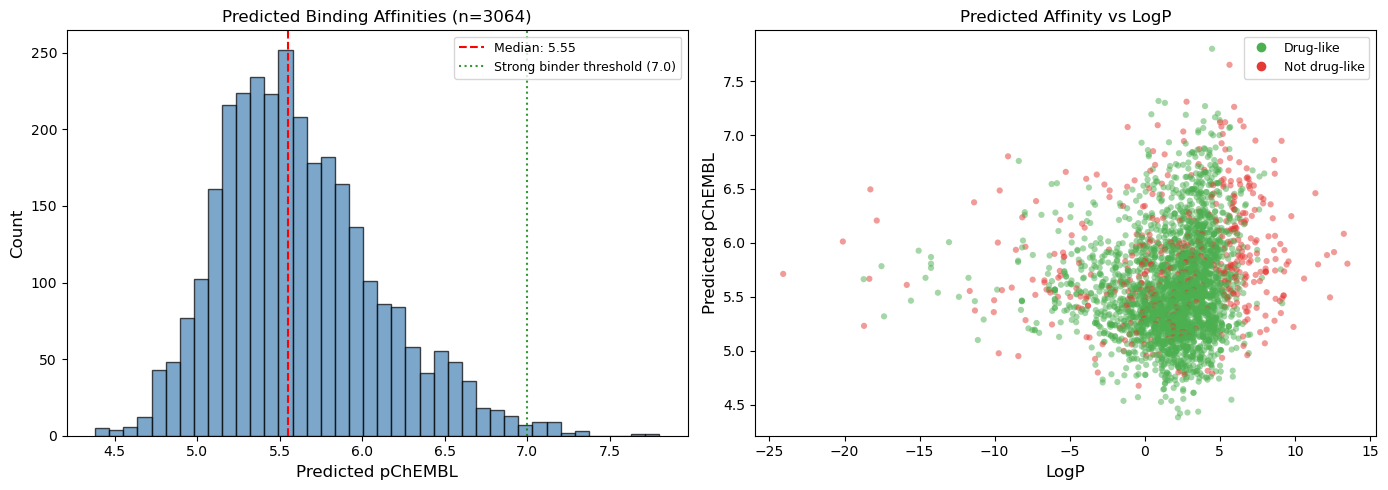

Saved: models/virtual_screening_results.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of predicted pChEMBL
axes[0].hist(results['Predicted_pChEMBL'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(results['Predicted_pChEMBL'].median(), color='red', linestyle='--',
               label=f'Median: {results["Predicted_pChEMBL"].median():.2f}')
axes[0].axvline(7.0, color='green', linestyle=':', alpha=0.8,
               label='Strong binder threshold (7.0)')
axes[0].set_xlabel('Predicted pChEMBL', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Predicted Binding Affinities (n={len(results)})', fontsize=12)
axes[0].legend(fontsize=9)

# Scatter: LogP vs pChEMBL colored by drug-likeness
colors = ['#4CAF50' if dl else '#E53935' for dl in results['Drug_Like']]
axes[1].scatter(results['LogP'], results['Predicted_pChEMBL'], c=colors, alpha=0.5, s=20, edgecolors='none')
axes[1].set_xlabel('LogP', fontsize=12)
axes[1].set_ylabel('Predicted pChEMBL', fontsize=12)
axes[1].set_title('Predicted Affinity vs LogP', fontsize=12)
# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50', markersize=8, label='Drug-like'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=8, label='Not drug-like'),
]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('../models/virtual_screening_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: models/virtual_screening_results.png')

## 5.6 Top Candidates

We present the top 20 drug-like compounds ranked by predicted EGFR binding affinity,
along with 2D structure visualizations of the top 10. These represent potential
repurposing candidates for EGFR-driven cancers.

In [7]:
# Top 20 table
top20_cols = ['pref_name', 'molecule_chembl_id', 'Predicted_pChEMBL', 'MW', 'LogP',
              'HBA', 'HBD', 'TPSA', 'Lipinski_Violations']
print('Top 20 Drug-Like Candidates by Predicted EGFR Binding Affinity:')
print('=' * 100)
print(drug_like[top20_cols].head(20).to_string(index=False))
print('=' * 100)

Top 20 Drug-Like Candidates by Predicted EGFR Binding Affinity:
                  pref_name molecule_chembl_id  Predicted_pChEMBL      MW     LogP  HBA  HBD   TPSA  Lipinski_Violations
                  SOTORASIB      CHEMBL4535757           7.800469 560.605  4.48142    7    1 104.45                    1
                HYDRALAZINE       CHEMBL276832           7.316351 160.180  0.91540    4    2  63.83                    0
  HYDRALAZINE HYDROCHLORIDE       CHEMBL542541           7.298773 196.641  1.33720    4    2  63.83                    0
       OSIMERTINIB MESYLATE      CHEMBL3545063           7.268647 595.726  4.01380    9    3 141.92                    1
        DABRAFENIB MESYLATE      CHEMBL2105729           7.199612 615.681  4.86890    9    3 165.23                    1
          CHLORTETRACYCLINE       CHEMBL404520           7.192710 478.885  0.43900    9    6 181.62                    1
       RIBOCICLIB SUCCINATE      CHEMBL3707266           7.187657 552.636  2.73220    9  

Saved: models/top_candidates.png


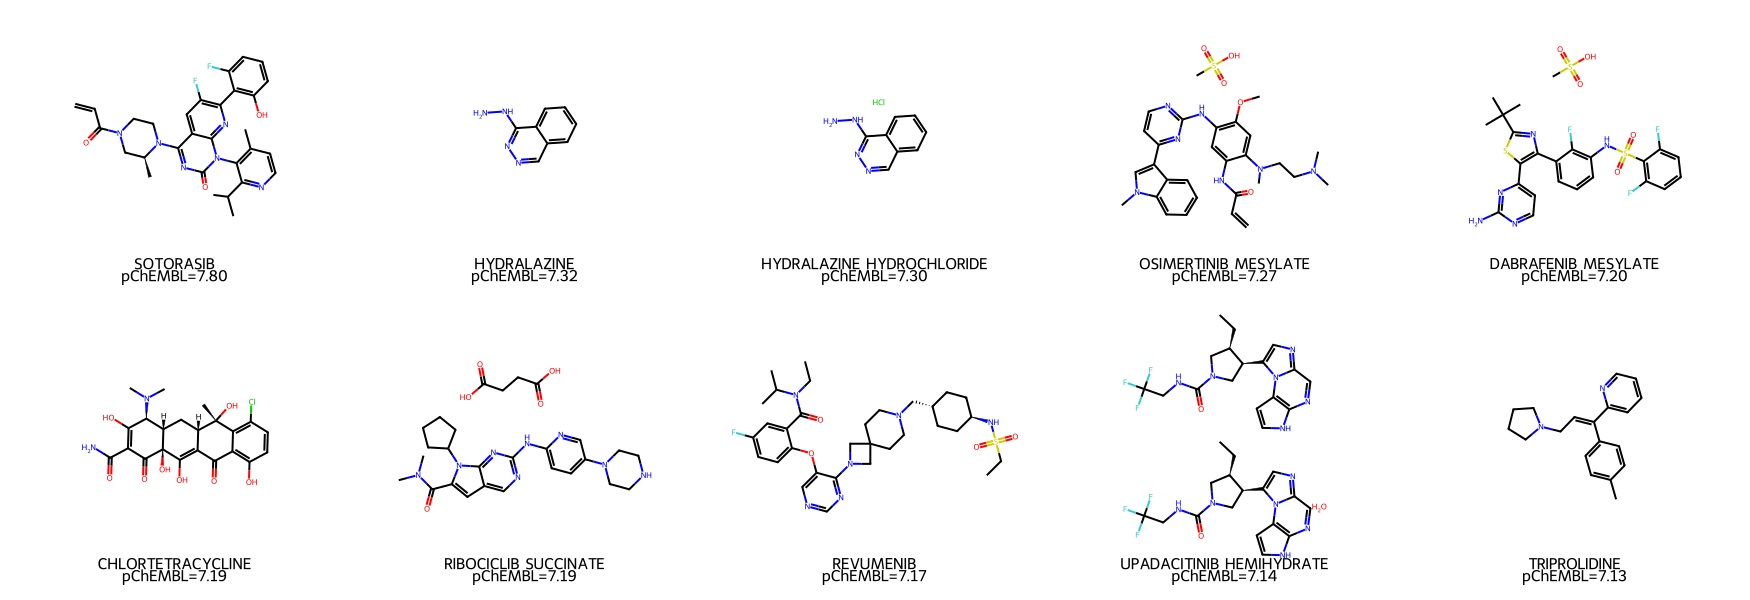

In [8]:
# Draw top 10 structures
top10 = drug_like.head(10)
top_mols = [Chem.MolFromSmiles(smi) for smi in top10['canonical_smiles']]
top_legends = [f"{row['pref_name']}\npChEMBL={row['Predicted_pChEMBL']:.2f}"
               for _, row in top10.iterrows()]

grid_img = Draw.MolsToGridImage(top_mols, molsPerRow=5, subImgSize=(350, 300), legends=top_legends)

if isinstance(grid_img, Image.Image):
    grid_img.save('../models/top_candidates.png')
else:
    pil_img = Image.open(BytesIO(grid_img.data))
    pil_img.save('../models/top_candidates.png')

print('Saved: models/top_candidates.png')
grid_img

In [9]:
# Save full results
results.to_csv('../data/processed/screening_results.csv', index=False)
drug_like.to_csv('../data/processed/top_candidates.csv', index=False)

print(f'Virtual Screening Summary')
print(f'========================')
print(f'  Library source: ChEMBL approved drugs (max_phase=4)')
print(f'  Total screened: {len(results)}')
print(f'  Drug-like candidates (\u22641 Lipinski violation): {len(drug_like)}')
print(f'  Strong predicted binders (pChEMBL \u2265 7): {(drug_like["Predicted_pChEMBL"] >= 7).sum()}')
print(f'  Predicted pChEMBL range: [{results["Predicted_pChEMBL"].min():.2f}, {results["Predicted_pChEMBL"].max():.2f}]')
print(f'  Top candidate: {drug_like.iloc[0]["pref_name"]} (pChEMBL={drug_like.iloc[0]["Predicted_pChEMBL"]:.2f})')
print(f'\nResults saved to data/processed/screening_results.csv and top_candidates.csv')

Virtual Screening Summary
  Library source: ChEMBL approved drugs (max_phase=4)
  Total screened: 3064
  Drug-like candidates (≤1 Lipinski violation): 2620
  Strong predicted binders (pChEMBL ≥ 7): 16
  Predicted pChEMBL range: [4.38, 7.80]
  Top candidate: SOTORASIB (pChEMBL=7.80)

Results saved to data/processed/screening_results.csv and top_candidates.csv
